In [1]:
from utils.detection.datasets import DETRDataset
from utils.detection.detr.transforms import (
    get_train_transform, 
    get_valid_transform,
    get_train_aug,
    transform_mosaic,
)

In [2]:
check = DETRDataset("/lustre1/work/d31086/valid/", "/lustre1/work/d31086/valid/", 400, ["__background__", "TC"], get_train_transform())

Checking images and labels...


/lustre0/home/d31086/test/lib/python3.13/site-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()


  0%|          | 0/242 [00:00<?, ?it/s]

In [3]:
from vision_transformers.detection.detr.model import DETRModel
model = DETRModel(num_classes=1, model="detr_resnet50")

Using cache found in /home/d31086/.cache/torch/hub/facebookresearch_detr_main
/lustre0/home/d31086/test/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/lustre0/home/d31086/test/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [4]:
import torch
state_dict = torch.load("/lustre1/work/d31086/vision_transformers_forked/runs/training/res_31/best_model.pth", map_location="cpu")

model.load_state_dict(state_dict, strict=False)

model.eval()

DETRModel(
  (model): DETR(
    (transformer): Transformer(
      (encoder): TransformerEncoder(
        (layers): ModuleList(
          (0-5): 6 x TransformerEncoderLayer(
            (self_attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
            )
            (linear1): Linear(in_features=256, out_features=2048, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
            (linear2): Linear(in_features=2048, out_features=256, bias=True)
            (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
            (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
            (dropout1): Dropout(p=0.1, inplace=False)
            (dropout2): Dropout(p=0.1, inplace=False)
          )
        )
      )
      (decoder): TransformerDecoder(
        (layers): ModuleList(
          (0-5): 6 x TransformerDecoderLayer(
            (self_attn): Multihead

In [51]:
N = 88

with torch.no_grad():
    out = model([check.__getitem__(N)[0]])

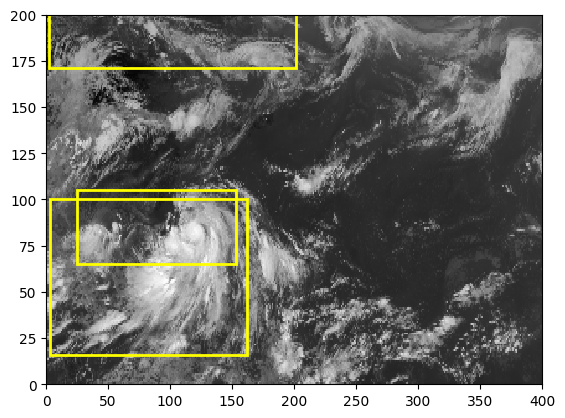

In [52]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import cv2

img = check.__getitem__(N)[0][0,...]
fig = plt.figure()
ax = fig.add_subplot(111)
ax.pcolormesh(img, cmap="binary")
plt.xlim([0,400])
plt.ylim([0,200])

for i in range(len(out['pred_boxes'][0])):
    logits = out['pred_logits'][0][i]
    soft_logits = torch.sigmoid(logits)
    max_index = torch.argmax(soft_logits)
    class_name = ["TC"]
    
    if soft_logits[max_index] > 0.5:

        box = out['pred_boxes'][0][i].numpy()
        cx, cy, w, h = box
        cx = cx * check.__getitem__(0)[0][0,...].shape[1]
        cy = cy * check.__getitem__(0)[0][0,...].shape[0]
        w = w * check.__getitem__(0)[0][0,...].shape[1]
        h = h * check.__getitem__(0)[0][0,...].shape[0]
        
        x1 = int(cx - (w//2))
        y1 = int(cy - (h//2))
        x2 = int(x1 + w)
        y2 = int(y1 + h)

        rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor='yellow', facecolor='none')
        ax.add_patch(rect) 